In [1]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path

from scipy import stats
from pmdarima import auto_arima
from pmdarima.arima import ndiffs, nsdiffs

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)

# Lấy chuỗi PM2.5 theo ngày
df_pm25 = df[['PM25']].resample('D').mean().asfreq('D')
df_pm25['PM25'] = df_pm25['PM25'].interpolate(limit_direction='both')


In [3]:

TRANSFORM = 'log'   # chọn 'identity' hoặc 'log' hoặc 'boxcox'

def transform_series(s, method='identity'):
    if method=='identity':
        return s.copy(), None
    if method=='log':
        return np.log(s + 1e-6), None
    if method=='boxcox':
        y = s + 1e-6
        y2, lam = stats.boxcox(y)
        return pd.Series(y2, index=s.index), lam
    raise ValueError("Phương pháp transform không hợp lệ")

def inv_transform(s_t, method='identity', lam=None):
    if method=='identity': return s_t
    if method=='log': return np.exp(s_t) - 1e-6
    if method=='boxcox':
        try:
            return stats.inv_boxcox(s_t, lam)
        except Exception:
            if lam == 0:
                return np.exp(s_t) - 1e-6
            return np.power(s_t * lam + 1, 1/lam) - 1e-6
    raise ValueError("Phương pháp inverse không hợp lệ")

# Kiểm tra transform → inverse nhanh
y_sample = df_pm25['PM25'].dropna().iloc[:20]
y_tst, lam_test = transform_series(y_sample, method=TRANSFORM)
print("Sai số max khi transform→inv (20 mẫu đầu):", np.nanmax(np.abs(inv_transform(y_tst, TRANSFORM, lam_test) - y_sample)))


Sai số max khi transform→inv (20 mẫu đầu): 4.263256414560601e-14


In [4]:
# CELL 4: chia dữ liệu theo thời gian (80/20)
y = df_pm25['PM25'].dropna()
cutoff_test = int(len(y) * 0.8)

# Áp transform cho toàn bộ rồi cắt (để train/test cùng thang transform)
y_all_t, lam = transform_series(y, method=TRANSFORM)
y_train = y_all_t.iloc[:cutoff_test].copy()
y_test  = y_all_t.iloc[cutoff_test:].copy()

print("Train:", y_train.index.min(), "->", y_train.index.max(), "số bản ghi:", len(y_train))
print("Test :", y_test.index.min(), "->", y_test.index.max(), "số bản ghi:", len(y_test))


Train: 2023-01-01 00:00:00 -> 2024-08-06 00:00:00 số bản ghi: 584
Test : 2024-08-07 00:00:00 -> 2024-12-31 00:00:00 số bản ghi: 147


Kiểm ADF/KPSS trên y_train (thang gốc):
ADF stat: -5.8305 | p-value: 0.0000
Giá trị tới hạn: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}
=> stationary (không cần diff)
KPSS stat: 0.2720 | p-value: 0.1000
Giá trị tới hạn: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
=> stationary (không reject H0)
pmdarima gợi ý: d = 0 , D = 0 (m=7)


C:\Users\hungd\AppData\Local\Temp\ipykernel_6916\1559564086.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), regression='c', nlags='auto')


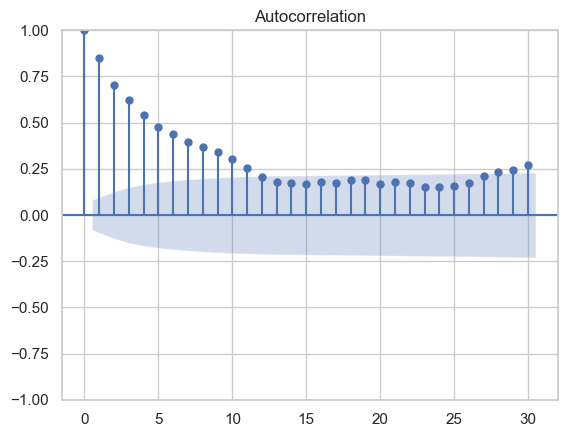

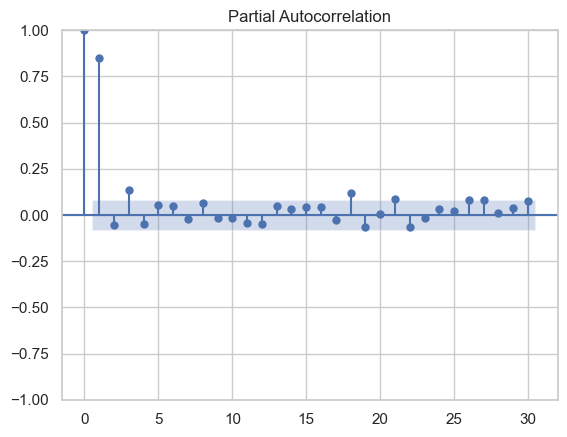

In [5]:
# CELL 5: kiểm ADF/KPSS để quyết differencing, vẽ ACF/PACF để gợi ý p/q
def adf_test(series):
    res = adfuller(series.dropna(), autolag='AIC')
    print("ADF stat: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Giá trị tới hạn:", res[4])
    print("=>", "stationary (không cần diff)" if res[1]<0.05 else "non-stationary (cần diff)")

def kpss_test(series):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print("KPSS stat: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Giá trị tới hạn:", res[3])
    print("=>", "non-stationary (reject H0)" if res[1]<0.05 else "stationary (không reject H0)")

# Dùng y_train (thang gốc) để kiểm
y_train_goc = y.iloc[:cutoff_test]
print("Kiểm ADF/KPSS trên y_train (thang gốc):")
adf_test(y_train_goc)
kpss_test(y_train_goc)

# pmdarima gợi ý d và D
d_suggest = ndiffs(y_train_goc, test='adf')
D_suggest = nsdiffs(y_train_goc, m=7, test='ch')
print("pmdarima gợi ý: d =", d_suggest, ", D =", D_suggest, "(m=7)")

# Vẽ ACF và PACF để tham khảo (gốc)
plot_acf(y_train_goc.dropna(), lags=30); plt.show()
plot_pacf(y_train_goc.dropna(), lags=30, method='ywm'); plt.show()


In [ ]:
# CELL 6: chạy auto_arima để gợi ý order (p,d,q) và seasonal_order

step = auto_arima(y_train, seasonal=True, m=30, trace=False,
                  max_p=7, max_q=4, max_P=2, max_Q=2,
                  d=None, D=None, stepwise=True, error_action='ignore', suppress_warnings=True)
order0 = step.order
seasonal0 = step.seasonal_order
print("auto_arima gợi ý:", order0, seasonal0)

# Tạo một neighborhood nhỏ quanh đề xuất để thử nghiệm
p0,d0,q0 = order0
p_range = list(range(max(0,p0-1), p0+2))
q_range = list(range(max(0,q0-1), q0+2))
candidates = [(p,d0,q) for p in p_range for q in q_range]
print("Các candidate sẽ thử:", candidates)


In [30]:
print(type(df.index), df.index.inferred_type, 'Local Time' in df.columns)
# mong muốn: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns] True/False


<class 'pandas.core.indexes.range.RangeIndex'> integer True


In [ ]:
# 0) Bảo đảm df có DatetimeIndex hoặc dùng cột 'Local Time'
if not isinstance(df.index, pd.DatetimeIndex):
    if 'Local Time' in df.columns:
        df['Local Time'] = pd.to_datetime(df['Local Time'], errors='coerce')
        df = df.set_index('Local Time').sort_index()
    else:
        raise ValueError("df không có DatetimeIndex và cũng không có cột 'Local Time'!")

# 1) Kỳ nghỉ (có thể thay bằng thư viện 'holidays' để tự động)
holiday_periods = {
    'Tết 2023': ('2023-01-20', '2023-01-26'),
    'Lễ 30/4-1/5 2023': ('2023-04-29', '2023-05-03'),
    'Lễ 2/9 2023': ('2023-08-31', '2023-09-04'),
    'Tết Dương 2024': ('2023-12-30', '2024-01-01'),
    'Tết 2024': ('2024-02-08', '2024-02-14'),
    'Lễ 30/4-1/5 2024': ('2024-04-27', '2024-05-01'),
    'Lễ 2/9 2024': ('2024-08-31', '2024-09-03'),
}

# 2) Xây exog_df (daily)
exog_candidates = ['PM10','NO2','SO2','pressure','temperature','wind_speed','rain','rain_hours','humidity']
exog_candidates = [c for c in exog_candidates if c in df.columns]

exog_df = df[exog_candidates].resample('D').mean().asfreq('D')

# 3) Cờ weekend/holiday (+lag)
exog_df['IsWeekend'] = exog_df.index.dayofweek.isin([5,6]).astype(int)
exog_df['IsHoliday'] = 0
for _, (start, end) in holiday_periods.items():
    exog_df.loc[(exog_df.index >= start) & (exog_df.index <= end), 'IsHoliday'] = 1
exog_df['IsHoliday_lag1'] = exog_df['IsHoliday'].shift(1).fillna(0)
exog_df['IsHoliday_lag2'] = exog_df['IsHoliday'].shift(2).fillna(0)

# 4) Lag-1 cho biến numeric
for c in exog_candidates:
    exog_df[f"{c}_lag1"] = exog_df[c].shift(1)

# 5) Corr với PM2.5 (align đúng series daily)
pm25_daily = df_pm25['PM25'].asfreq('D')  # đảm bảo là Series daily
corr_with_pm25 = exog_df.join(pm25_daily).corr()['PM25'].drop('PM25').sort_values(ascending=False)
print("Tương quan với PM2.5 (daily):\n", corr_with_pm25.head(20))

# 6) VIF (loại cột rỗng/variance~0, dropna tạm thời để tính VIF)
X_for_vif = exog_df.copy()
keep_cols = [c for c in X_for_vif.columns if X_for_vif[c].notna().sum() > 10 and X_for_vif[c].std(skipna=True) > 1e-6]
X_for_vif = X_for_vif[keep_cols].dropna()

X_vif_scaled = (X_for_vif - X_for_vif.mean()) / X_for_vif.std(ddof=0)
vif_df = pd.DataFrame({
    'feature': X_vif_scaled.columns,
    'VIF': [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]
}).sort_values('VIF', ascending=False)
print("VIF ban đầu (top):\n", vif_df.head(15))

# 7) Chọn biến: |corr| > 0.10 và VIF < 10 (lọc lặp)
corr_th, vif_th = 0.05, 10.0
sel = [c for c in corr_with_pm25.index if (abs(corr_with_pm25.loc[c]) > corr_th) and (c in X_vif_scaled.columns)]

sel_iter = sel.copy()
while len(sel_iter) > 1:
    Xtmp = X_for_vif[sel_iter]
    Xtmp = (Xtmp - Xtmp.mean()) / Xtmp.std(ddof=0)
    vifs = pd.Series([variance_inflation_factor(Xtmp.values, i) for i in range(Xtmp.shape[1])],
                     index=sel_iter).sort_values(ascending=False)
    if vifs.iloc[0] <= vif_th:
        break
    sel_iter.remove(vifs.index[0])

sel_final = sel_iter
print("Biến được chọn (|corr|>0.05 & VIF<10):", sel_final)


Tương quan với PM2.5 (daily):
 PM10              0.573323
NO2               0.496895
PM10_lag1         0.471856
NO2_lag1          0.460454
SO2               0.281411
SO2_lag1          0.228096
IsHoliday         0.032601
IsHoliday_lag1   -0.001788
IsHoliday_lag2   -0.021642
IsWeekend        -0.026753
Name: PM25, dtype: float64
VIF ban đầu (top):
           feature       VIF
5  IsHoliday_lag1  4.921851
4       IsHoliday  2.800608
6  IsHoliday_lag2  2.788351
0            PM10  2.709314
7       PM10_lag1  2.698158
9        SO2_lag1  2.599890
2             SO2  2.576386
1             NO2  2.385129
8        NO2_lag1  2.380930
3       IsWeekend  1.025096
✅ Biến được chọn (|corr|>0.10 & VIF<10): ['PM10', 'NO2', 'PM10_lag1', 'NO2_lag1', 'SO2', 'SO2_lag1']


In [ ]:
# CELL 8: hàm walk-forward 1-step (fit lại mỗi bước) và metric helper
def sMAPE(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

def wf_forecast(y_train_tf, y_test_tf, order=(1,1,2), seasonal_order=(0,0,0,0),
                exog_train=None, exog_test=None, transform=TRANSFORM, lam=lam):
    """
    Walk-forward 1-step forecast (fix lỗi append bằng pd.concat).
    y_train_tf, y_test_tf: pandas.Series (DatetimeIndex).
    exog_train/exog_test: pandas.DataFrame aligned (optional).
    Trả về: preds_goc, lo_goc, hi_goc, runtime_seconds
    """
    import time, pandas as pd
    # kiểm tra
    if not isinstance(y_train_tf, pd.Series) or not isinstance(y_test_tf, pd.Series):
        raise TypeError("y_train_tf và y_test_tf phải là pandas.Series (DatetimeIndex).")

    history = y_train_tf.copy()
    preds, lo, hi = [], [], []
    t0 = time.time()

    for t in range(len(y_test_tf)):
        # Fit model
        if exog_train is None:
            model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            f = res.get_forecast(steps=1)
        else:
            # đảm bảo exog_hist có cùng index với history
            exog_hist = exog_train.reindex(history.index)
            model = SARIMAX(history, exog=exog_hist, order=order, seasonal_order=seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            # exog_test.iloc[[t]] là DataFrame 1 hàng
            f = res.get_forecast(steps=1, exog=exog_test.iloc[[t]])

        preds.append(float(f.predicted_mean))
        ci = f.conf_int(alpha=0.05).iloc[0]
        lo.append(float(ci.iloc[0])); hi.append(float(ci.iloc[1]))

        # cập nhật history bằng pd.concat (an toàn)
        obs = y_test_tf.iloc[t:t+1]   # vẫn là Series 1 phần tử
        history = pd.concat([history, obs])

    runtime = time.time() - t0
    preds = pd.Series(preds, index=y_test_tf.index)
    lo = pd.Series(lo, index=y_test_tf.index)
    hi = pd.Series(hi, index=y_test_tf.index)

    # đưa về thang gốc
    preds_goc = inv_transform(preds, method=transform, lam=lam)
    lo_goc = inv_transform(lo, method=transform, lam=lam)
    hi_goc = inv_transform(hi, method=transform, lam=lam)

    return preds_goc, lo_goc, hi_goc, runtime

def rmse(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    y_true, y_pred = y_true.align(y_pred, join='inner')
    m = ~(y_true.isna() | y_pred.isna())
    return float(np.sqrt(mean_squared_error(y_true[m].astype(float), y_pred[m].astype(float))))


Chạy ARIMA (1, 1, 2)
ARIMA xong trong 8.61 giây
Chạy SARIMA (1, 1, 2) (0, 0, 1, 30)
SARIMA xong trong 205.17 giây
Bảng so sánh (sắp theo MAE):
    model        mae       rmse      sMAPE      time_s
0  SARIMA  15.335615  21.256166  28.801481  205.173565
1   ARIMA  15.372079  21.401862  28.791032    8.608925


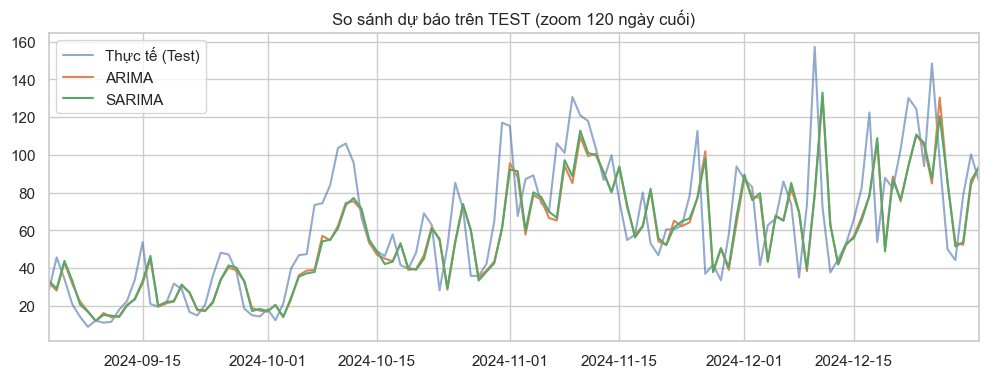

In [23]:
# CELL 9: chạy 3 mô hình, in MAE/RMSE/sMAPE và vẽ so sánh
# Chuẩn bị exog_final theo sel_final từ CELL 7
# exog_final = sel_final.copy()
# # Nếu muốn bổ sung lag cụ thể vd 'PM10_lag1' đã được thêm sẵn, làm như sau:
# if 'PM10_lag1' in exog_df.columns and 'PM10_lag1' not in exog_final:
#     exog_final.append('PM10_lag1')

# print("Exog cuối cùng sử dụng:", exog_final)

# # Chuẩn exog đã chuẩn hoá và align index y_train/y_test
# exog_scaled_all = pd.DataFrame(scaler.transform(exog_df), index=exog_df.index, columns=exog_df.columns)
# exog_train_sel = exog_scaled_all.loc[y_train.index, exog_final] if len(exog_final)>0 else None
# exog_test_sel  = exog_scaled_all.loc[y_test.index, exog_final]  if len(exog_final)>0 else None

# ARIMA
print("Chạy ARIMA", order0)
pred_arima, lo_ar, hi_ar, t_ar = wf_forecast(y_train, y_test, order=order0, seasonal_order=(0,0,0,0),
                                            exog_train=None, exog_test=None, transform=TRANSFORM, lam=lam)
print("ARIMA xong trong", round(t_ar,2), "giây")

# SARIMA
seasonal_candidate = seasonal0 if seasonal0!=(0,0,0,0) else (1,0,1,7)
print("Chạy SARIMA", order0, seasonal_candidate)
pred_sarima, lo_s, hi_s, t_s = wf_forecast(y_train, y_test, order=order0, seasonal_order=seasonal_candidate,
                                           exog_train=None, exog_test=None, transform=TRANSFORM, lam=lam)
print("SARIMA xong trong", round(t_s,2), "giây")

# SARIMAX nếu có exog
# if exog_train_sel is not None and exog_train_sel.shape[1] > 0:
#     print("Chạy SARIMAX với exog")
#     pred_sarimax, lo_x, hi_x, t_x = wf_forecast(y_train, y_test, order=order0, seasonal_order=seasonal_candidate,
#                                                 exog_train=exog_train_sel, exog_test=exog_test_sel,
#                                                 transform=TRANSFORM, lam=lam)
#     print("SARIMAX xong trong", round(t_x,2), "giây")
# else:
#     pred_sarimax = lo_x = hi_x = None
#     print("Không có exog -> bỏ SARIMAX")

# Tính metric trên thang gốc
y_test_goc = inv_transform(y_test, TRANSFORM, lam)
results = []
results.append({'model':'ARIMA','mae':mean_absolute_error(y_test_goc,pred_arima),'rmse':rmse(y_test_goc,pred_arima),'sMAPE':sMAPE(y_test_goc,pred_arima),'time_s':t_ar})
results.append({'model':'SARIMA','mae':mean_absolute_error(y_test_goc,pred_sarima),'rmse':rmse(y_test_goc,pred_sarima),'sMAPE':sMAPE(y_test_goc,pred_sarima),'time_s':t_s})
# if pred_sarimax is not None:
#     results.append({'model':'SARIMAX','mae':mean_absolute_error(y_test_goc,pred_sarimax),'rmse':rmse(y_test_goc,pred_sarimax),'sMAPE':sMAPE(y_test_goc,pred_sarimax),'time_s':t_x})

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh (sắp theo MAE):")
print(res_df)

# Vẽ so sánh (zoom 120 ngày cuối)
plt.figure(figsize=(12,4))
plt.plot(y_test_goc, label='Thực tế (Test)', color='C0', alpha=0.6)
plt.plot(pred_arima, label='ARIMA', color='C1')
plt.plot(pred_sarima, label='SARIMA', color='C2')
# if pred_sarimax is not None: plt.plot(pred_sarimax, label='SARIMAX', color='C3')
plt.legend(); plt.title('So sánh dự báo trên TEST (zoom 120 ngày cuối)')
plt.xlim(y_test_goc.index[-120], y_test_goc.index[-1])
plt.show()


In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# RMSE an toàn (tương thích mọi phiên bản sklearn)
def rmse_safe(y_true, y_pred):
    # chuyển về numpy
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # align: nếu có NaN hoặc khác dài, lấy phần đồng thời không-NaN
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

# sMAPE (nếu chưa có)
def sMAPE(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    yt = y_true[mask]; yp = y_pred[mask]
    return np.mean(2*np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100

# build results an toàn (dùng rmse_safe)
y_test_goc = inv_transform(y_test, TRANSFORM, lam)  # đã có trước

results = []
# đảm bảo pred_* là numpy / series với cùng index; nếu không, dùng .values
for name, pred, t in [('ARIMA', pred_arima, t_ar), ('SARIMA', pred_sarima, t_s)]:
    # align by index if preds are Series
    if hasattr(pred, 'index'):
        # reindex pred to y_test_goc index (won't create leak, chỉ align)
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)

    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':name, 'mae':mae, 'rmse':rm, 'sMAPE':sm, 'time_s':t})

# nếu bạn có pred_sarimax, thêm tương tự
if 'pred_sarimax' in globals() and pred_sarimax is not None:
    pred = pred_sarimax
    if hasattr(pred, 'index'):
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)
    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':'SARIMAX','mae':mae,'rmse':rm,'sMAPE':sm,'time_s':t_x})

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh (sắp theo MAE):")
print(res_df)


Bảng so sánh (sắp theo MAE):
    model        mae       rmse      sMAPE      time_s
0  SARIMA  15.335615  21.256166  28.801481  205.173565
1   ARIMA  15.372079  21.401862  28.791032    8.608925


Model tốt nhất: SARIMA MAE: 15.335615399227938
                                      SARIMAX Results                                       
Dep. Variable:                                 PM25   No. Observations:                  584
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 30)   Log Likelihood                -195.007
Date:                              Mon, 10 Nov 2025   AIC                            400.014
Time:                                      13:30:17   BIC                            421.563
Sample:                                  01-01-2023   HQIC                           408.435
                                       - 08-06-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6093      0.052     11.637      0.

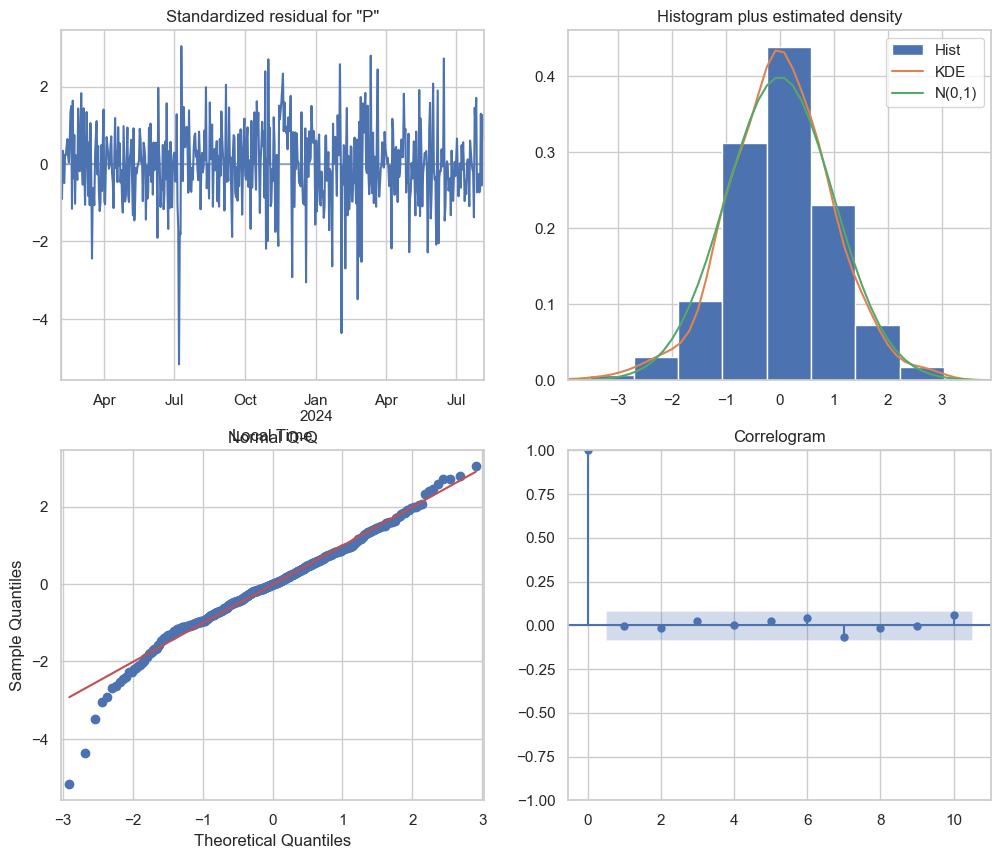

Ljung-Box p(12): 0.5587782232893697
Jarque-Bera p: 0.0 skew: 1.8382517257266269 kurtosis: 26.37010708181182


In [25]:
# CELL 10: diagnostics cho model tốt nhất và lưu model + kết quả
best = res_df.iloc[0]
print("Model tốt nhất:", best['model'], "MAE:", best['mae'])

# Fit lại final model trên y_train (transform)
if best['model'] == 'ARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=(0,0,0,0),
                          enforce_stationarity=False, enforce_invertibility=False)
elif best['model'] == 'SARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)
# else:  # SARIMAX
#     model_final = SARIMAX(y_train, exog=exog_train_sel, order=order0, seasonal_order=seasonal_candidate,
#                           enforce_stationarity=False, enforce_invertibility=False)

res_final = model_final.fit(disp=False)
print(res_final.summary())

# Vẽ diagnostics (residuals)
res_final.plot_diagnostics(figsize=(12,10))
plt.show()

# Kiểm Ljung-Box và Jarque-Bera để kiểm residual
p_lb = float(acorr_ljungbox(res_final.resid.dropna(), lags=[12], return_df=True)["lb_pvalue"].iloc[0])
jb_stat, jb_p, skew, kurt = jarque_bera(res_final.resid.dropna())
print("Ljung-Box p(12):", p_lb)
print("Jarque-Bera p:", jb_p, "skew:", skew, "kurtosis:", kurt)

